# Getting Started with xndbc

This notebook introduces the main `xndbc` workflow for discovering NOAA NDBC stations and loading buoy observations into `xarray` datasets.

It covers station discovery, geographic filtering, historical standard meteorological data, realtime observations, ADCP current-meter data, and spectral wave data. Several cells make live requests to NDBC data services, so execution time and exact station availability can vary.


In [1]:
import xndbc
import numpy as np
import matplotlib.pyplot as plt
from helpers import compute_data_coverage, plot_stations

print(f"xndbc version: {xndbc.__version__}")

/Users/anthonymeza/miniforge3/envs/xbuoy-test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xndbc version: 0.1.0


## 1. List Available Stations

Start by requesting the full NDBC station catalog. `list_available(mode=None)` returns station metadata, including station IDs and geographic coordinates, as an `xarray.Dataset`.


In [2]:
# Get all buoy stations
stations = xndbc.list_available(mode=None) #takes a while to pull from NDBC database! 
print(f"Total stations: {len(stations.station_id)}")
stations

Total stations: 1933


<xarray.Dataset> Size: 62kB
Dimensions:     (station_id: 1933)
Coordinates:
  * station_id  (station_id) object 15kB '0y2w3' '13001' ... 'yrsv2' 'zbqn7'
    latitude    (station_id) float64 15kB 44.79 12.0 21.0 ... 37.23 37.41 33.95
    longitude   (station_id) float64 15kB -87.31 -23.0 -23.0 ... -76.71 -77.94
Data variables:
    notes       (station_id) object 15kB ' ' ... 'Right whales are active off...

## 2. Filter Stations by Region

Use longitude and latitude bounds to focus the station catalog on a region of interest. This example selects stations in the Caribbean.


In [3]:
caribbean = xndbc.list_available(
    mode=None,
    lon_min=-85,
    lon_max=-60,
    lat_min=10,
    lat_max=25,
)
print(f"Caribbean stations: {len(caribbean.station_id)}")

Caribbean stations: 83


## 3. Visualize Station Locations

Plot the filtered stations on a map to confirm that the selected bounds captured the intended region before requesting observation data.


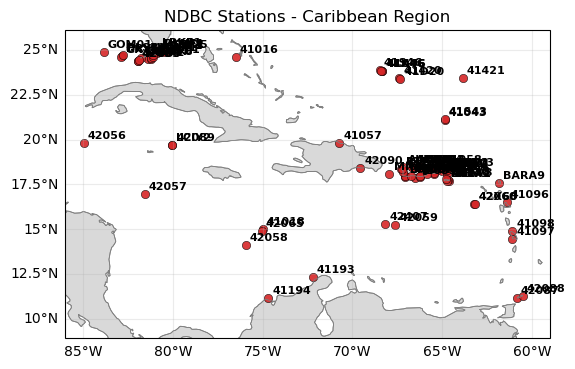

In [4]:
# Plot Caribbean stations
fig, ax = plot_stations(caribbean)
ax.set_extent([-86, -59, 9, 26])
ax.set_title("NDBC Stations - Caribbean Region")
plt.show()

## 4. Historical Coverage in the Region

Use the historical standard meteorological index to find files for the selected Caribbean stations. The example chooses the most recent year represented in the regional index, fetches daily observations, and computes coverage for each time-dependent variable.


In [5]:
available_stdmet = xndbc.list_available(mode="stdmet").to_dataframe()
caribbean_ids = [str(station_id) for station_id in caribbean.station_id.values]
caribbean_stdmet = available_stdmet[available_stdmet.station_id.isin(caribbean_ids)]
stdmet_year = int(caribbean_stdmet.year.max())
stdmet_stations = sorted(caribbean_stdmet.loc[caribbean_stdmet.year == stdmet_year, "station_id"].unique())

regional_data = xndbc.fetch_data(
    station_ids=stdmet_stations,
    years=stdmet_year,
    sample_rate="D",
)
regional_coverage = compute_data_coverage(regional_data)

regional_coverage

Fetching stations: 100%|██████████| 30/30 [00:19<00:00,  1.50station/s]


<xarray.Dataset> Size: 4kB
Dimensions:        (station_id: 30)
Coordinates:
  * station_id     (station_id) <U5 600B '41043' '41046' ... 'smkf1' 'vcaf1'
    latitude       (station_id) float64 240B 21.09 23.84 18.25 ... 24.63 24.71
    longitude      (station_id) float64 240B -64.86 -68.34 ... -81.11 -81.11
Data variables: (12/13)
    WDIR_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 47.4 97.81
    WSPD_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 47.4 97.81
    GST_coverage   (station_id) float64 240B 100.0 69.59 99.18 ... 47.4 97.81
    WVHT_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 0.0 0.0 0.0
    DPD_coverage   (station_id) float64 240B 100.0 69.59 99.18 ... 0.0 0.0 0.0
    APD_coverage   (station_id) float64 240B 100.0 69.59 0.0 0.0 ... 0.0 0.0 0.0
    ...             ...
    PRES_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 47.4 0.0
    ATMP_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 47.4 91.78
    WTMP_coverage  (station_id) float64 240B 100.0 69.59 99.18 ... 0.0 91.78
    DEWP_coverage  (station_id) float64 240B 100.0 69.59 0.0 ... 0.0 47.4 0.0
    VIS_coverage   (station_id) float64 240B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    TIDE_coverage  (station_id) float64 240B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

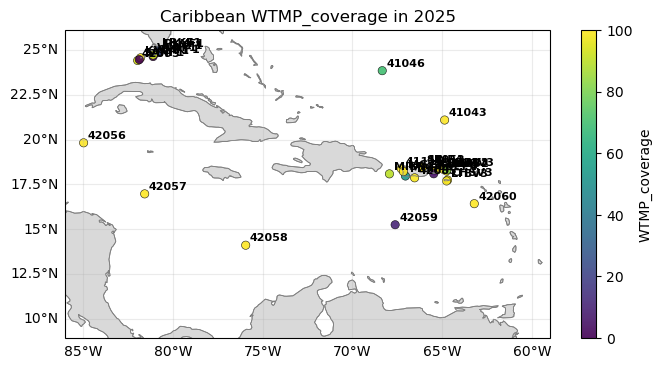

In [6]:
coverage_variable = "WTMP_coverage" if "WTMP_coverage" in regional_coverage else list(regional_coverage.data_vars)[0]
fig, ax = plot_stations(regional_coverage, variable=coverage_variable)
ax.set_extent([-86, -59, 9, 26])
ax.set_title(f"Caribbean {coverage_variable} in {stdmet_year}")
plt.show()

## 5. Water Temperature Across the Region

Plot water temperature (`WTMP`) across the stations that have data. This view is useful for comparing temporal coverage and broad regional patterns across the selected stations.


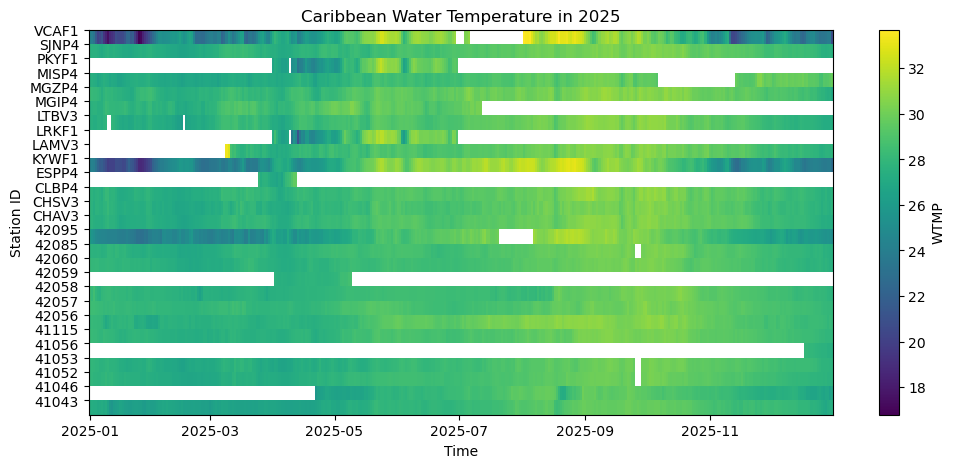

In [7]:
wtmp = regional_data["WTMP"].dropna("station_id", how="all")
station_idx = np.arange(len(wtmp.station_id))

plt.figure(figsize=(12, 5))
plt.pcolormesh(wtmp.time, station_idx, wtmp, cmap="viridis", shading="auto")
plt.yticks(station_idx + 0.5, [str(station).upper() for station in wtmp.station_id.values])
plt.xlabel("Time")
plt.ylabel("Station ID")
plt.colorbar(label="WTMP")
plt.title(f"Caribbean Water Temperature in {stdmet_year}")
plt.show()

## 6. Historical Availability

Inspect the filtered historical index directly. The table shows which Caribbean stations have standard meteorological files available and which years those files cover.


In [8]:
caribbean_stdmet.head()

,station_id,mode,year,filename,url
file,,,,,
353,41016,stdmet,1992,41016h1992.txt.gz,https://www.ndbc.noaa.gov/data/historical/stdm...
354,41016,stdmet,1993,41016h1993.txt.gz,https://www.ndbc.noaa.gov/data/historical/stdm...
355,41016,stdmet,1994,41016h1994.txt.gz,https://www.ndbc.noaa.gov/data/historical/stdm...
356,41016,stdmet,1995,41016h1995.txt.gz,https://www.ndbc.noaa.gov/data/historical/stdm...
359,41018,stdmet,1994,41018h1994.txt.gz,https://www.ndbc.noaa.gov/data/historical/stdm...


## 7. Realtime Data

Realtime feeds use the same `fetch_data` API. This section selects one station from the historical dataset and requests recent hourly standard meteorological observations.


In [9]:
realtime_station = str(regional_data.station_id.isel(station_id=0).item())

realtime = xndbc.fetch_data(
    realtime_station,
    data_type="realtime",
    sample_rate="H",
)

realtime

Fetching stations: 100%|██████████| 1/1 [00:01<00:00,  1.53s/station]


<xarray.Dataset> Size: 132kB
Dimensions:     (station_id: 1, time: 1096)
Coordinates:
  * station_id  (station_id) <U5 20B '41043'
    latitude    (station_id) float64 8B 21.09
    longitude   (station_id) float64 8B -64.86
  * time        (time) datetime64[us] 9kB 2026-05-04 ... 2026-06-18T15:00:00
Data variables: (12/14)
    WDIR        (station_id, time) float64 9kB 105.0 100.0 96.67 ... 90.0 92.0
    WSPD        (station_id, time) float64 9kB 4.0 4.167 4.333 ... 6.667 6.2
    GST         (station_id, time) float64 9kB 5.333 4.833 5.167 ... 8.0 8.0 8.0
    WVHT        (station_id, time) float64 9kB 1.1 1.1 1.1 1.067 ... 1.3 1.4 1.3
    DPD         (station_id, time) float64 9kB 11.0 10.5 10.0 ... 8.0 6.0 6.0
    APD         (station_id, time) float64 9kB 6.4 6.567 6.467 ... 5.0 4.95 5.0
    ...          ...
    ATMP        (station_id, time) float64 9kB 26.73 26.82 26.8 ... 27.63 27.54
    WTMP        (station_id, time) float64 9kB 27.45 27.53 27.6 ... 28.0 28.06
    DEWP        (station_id, time) float64 9kB 23.53 23.77 23.82 ... 22.93 22.92
    VIS         (station_id, time) float64 9kB nan nan nan nan ... nan nan nan
    PTDY        (station_id, time) float64 9kB 1.2 1.1 1.3 1.2 ... 0.8 0.6 0.6
    TIDE        (station_id, time) float64 9kB nan nan nan nan ... nan nan nan

## 8. ADCP Data in the Region

ADCP files contain current-meter observations across depth bins. `xndbc` reshapes these files onto a `depth_bin` dimension so current speed and direction can be inspected as structured `xarray` variables.


In [10]:
available_adcp = xndbc.list_available(mode="adcp").to_dataframe()
caribbean_adcp = available_adcp[available_adcp.station_id.isin(caribbean_ids)]
adcp_station = str(caribbean_adcp.station_id.iloc[0])
adcp_year = int(caribbean_adcp.year.iloc[0])

adcp = xndbc.fetch_data(
    adcp_station,
    years=adcp_year,
    sample_rate="D",
    mode="adcp",
)

adcp

Fetching stations: 100%|██████████| 1/1 [00:00<00:00,  2.02station/s]


<xarray.Dataset> Size: 211kB
Dimensions:     (station_id: 1, time: 300, depth_bin: 29)
Coordinates:
  * station_id  (station_id) <U5 20B '41051'
    latitude    (station_id) float64 8B 18.26
    longitude   (station_id) float64 8B -65.0
  * time        (time) datetime64[us] 2kB 2013-03-07 2013-03-08 ... 2013-12-31
  * depth_bin   (depth_bin) int64 232B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29
Data variables:
    DEP         (station_id, time, depth_bin) float64 70kB 1.5 2.5 ... 29.0 30.0
    DIR         (station_id, time, depth_bin) float64 70kB 112.5 154.2 ... 264.7
    SPD         (station_id, time, depth_bin) float64 70kB 11.52 16.48 ... 13.67

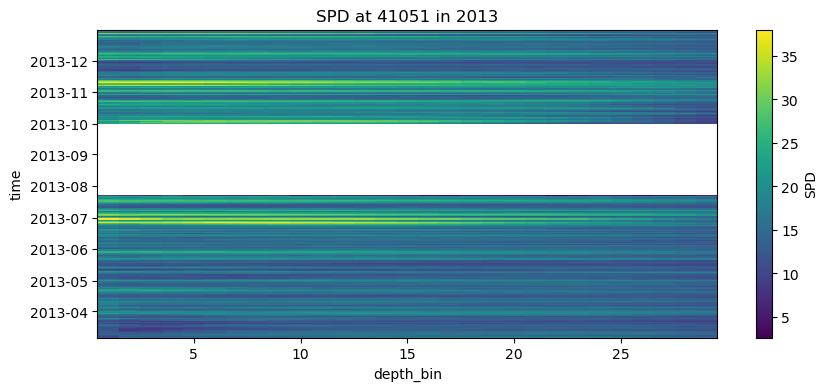

In [11]:
adcp_variable = "SPD" if "SPD" in adcp else list(adcp.data_vars)[0]
adcp[adcp_variable].isel(station_id=0).plot(figsize=(10, 4))
plt.title(f"{adcp_variable} at {adcp_station.upper()} in {adcp_year}")
plt.show()

## 9. Spectral Wave Data in the Region

Spectral wave-density files are reshaped onto a `frequency` dimension. This section finds an available spectral wave file in the region, fetches it, and plots the resulting wave spectrum data variable.


In [12]:
available_swden = xndbc.list_available(mode="swden").to_dataframe()
caribbean_swden = available_swden[available_swden.station_id.isin(caribbean_ids)]
spectral_station = str(caribbean_swden.station_id.iloc[0])
spectral_year = int(caribbean_swden.year.iloc[0])

spectral = xndbc.fetch_data(
    spectral_station,
    years=spectral_year,
    sample_rate="D",
    mode="swden",
)

spectral

Fetching stations: 100%|██████████| 1/1 [00:00<00:00,  4.46station/s]


<xarray.Dataset> Size: 14kB
Dimensions:     (station_id: 1, time: 45, frequency: 38)
Coordinates:
  * station_id  (station_id) <U5 20B '41018'
    latitude    (station_id) float64 8B 15.0
    longitude   (station_id) float64 8B -75.0
  * time        (time) datetime64[us] 360B 1996-01-01 1996-01-02 ... 1996-02-14
  * frequency   (frequency) float64 304B 0.03 0.04 0.05 0.06 ... 0.38 0.39 0.4
Data variables:
    SWDEN       (station_id, time, frequency) float64 14kB 0.0 0.0 ... 0.07292

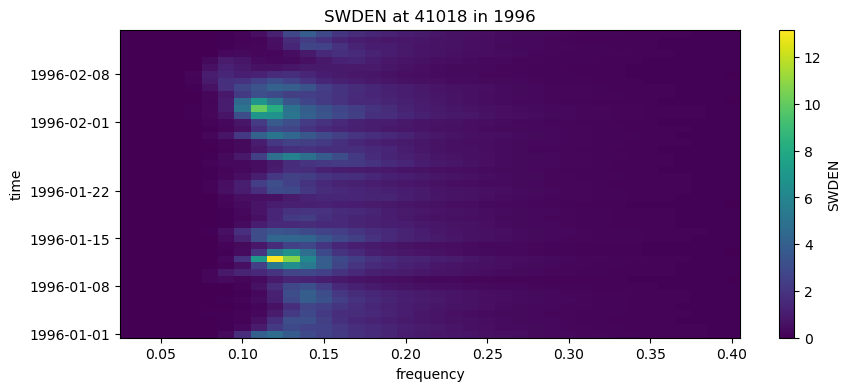

In [13]:
spectral_variable = "SWDEN" if "SWDEN" in spectral else list(spectral.data_vars)[0]
spectral[spectral_variable].isel(station_id=0).plot(figsize=(10, 4))
plt.title(f"{spectral_variable} at {spectral_station.upper()} in {spectral_year}")
plt.show()